# ♟️ Notebook 16 — The Infinite Curriculum
### Self-Play, MCTS, and AlphaZero

**Series**: RL Notebook Series · Act VI — Grandmasters · Post 16 of 17

---

## The Leap

Every RL agent we've built so far needs **something external** to learn from:
- Notebooks 01-13: an environment with a reward signal
- Notebooks 14-15: human preferences (GRPO, DPO)

But what about games like **chess** or **Go**, where:
- There's no reward until the game **ends** (win/loss/draw)
- The opponent is **adaptive** — they get better as you get better
- No human dataset can capture the full depth of play

### The AlphaZero Insight

What if the agent could be **its own teacher?**

| Era | System | Approach |
| :--- | :--- | :--- |
| 1997 | **Deep Blue** | Handcrafted evaluation + brute-force search |
| 2016 | **AlphaGo** | Human games + RL + MCTS |
| 2017 | **AlphaZero** | Self-play from scratch — zero human knowledge |

AlphaZero (Silver et al., 2017) starts from **random play** and within hours
surpasses all human knowledge in chess, Go, and shogi.

The secret? Three ingredients:
1. **Monte Carlo Tree Search (MCTS)** — look ahead by simulating games
2. **A neural network** — evaluate positions and suggest moves
3. **Self-play** — the agent plays against itself, creating an infinite curriculum

Today we'll build all three, step by step, on **Tic-Tac-Toe**.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from copy import deepcopy
from collections import defaultdict
import math
import random

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.3})
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## 1. The Tic-Tac-Toe Environment

Our arena is the classic 3x3 game. It's small enough to solve perfectly (only ~5,500 unique states),
yet it's a genuine **two-player zero-sum game** that exercises every component of AlphaZero.

Key design choices:
- `board`: 3x3 NumPy array (1 = Player 1, -1 = Player 2, 0 = empty)
- `clone()`: deep copy for MCTS simulation (search without mutating the real game)
- `get_canonical_board()`: returns the board from the **current player's perspective** — the neural network always sees itself as Player 1

In [16]:
class TicTacToe:
    """Tic-Tac-Toe environment for two-player self-play.
    
    Board encoding: 1 = current player's mark, -1 = opponent's mark, 0 = empty.
    Players alternate: player 1 starts, player -1 follows.
    """
    def __init__(self):
        self.board = np.zeros((3, 3), dtype=np.float32)
        self.current_player = 1  # 1 or -1
        self.done = False
        self.winner = None  # 1, -1, or 0 (draw)
    
    def clone(self):
        """Deep copy for MCTS simulation."""
        g = TicTacToe()
        g.board = self.board.copy()
        g.current_player = self.current_player
        g.done = self.done
        g.winner = self.winner
        return g
    
    def get_valid_actions(self):
        """Return list of valid action indices (0-8) for empty cells."""
        return [i for i in range(9) if self.board[i // 3, i % 3] == 0]
    
    def step(self, action):
        """Play action (0-8). Returns (reward, done).
        
        Reward is from the perspective of the player who just moved:
          +1 = win, -1 = loss, 0 = draw or game continues.
        """
        row, col = action // 3, action % 3
        assert self.board[row, col] == 0, f"Cell {action} is occupied!"
        assert not self.done, "Game is already over!"
        
        self.board[row, col] = self.current_player
        
        # Check for winner
        if self._check_winner(self.current_player):
            self.done = True
            self.winner = self.current_player
            return 1.0, True  # Current player wins
        
        # Check for draw
        if len(self.get_valid_actions()) == 0:
            self.done = True
            self.winner = 0
            return 0.0, True
        
        # Switch player
        self.current_player *= -1
        return 0.0, False
    
    def _check_winner(self, player):
        """Check if the given player has three in a row."""
        b = self.board
        # Rows, columns, diagonals
        for i in range(3):
            if all(b[i, :] == player) or all(b[:, i] == player):
                return True
        if b[0,0] == b[1,1] == b[2,2] == player:
            return True
        if b[0,2] == b[1,1] == b[2,0] == player:
            return True
        return False
    
    def get_canonical_board(self):
        """Board from the current player's perspective.
        
        The neural net always sees itself as player 1.
        If it's player -1's turn, we flip the signs.
        """
        return self.board * self.current_player
    
    def render(self):
        """Pretty-print the board."""
        symbols = {1: 'X', -1: 'O', 0: '.'}
        print('  0 1 2')
        for i in range(3):
            row_str = ' '.join(symbols[int(self.board[i, j])] for j in range(3))
            print(f'{i} {row_str}')
        status = 'ongoing'
        if self.done:
            status = f"winner: {symbols.get(self.winner, 'draw')}" if self.winner else "draw"
        print(f'  [{status}]\n')


def random_player(game):
    """Pick a random valid action."""
    return random.choice(game.get_valid_actions())


def play_game(player1_fn, player2_fn, verbose=False):
    """Play a full game. Returns the winner (1, -1, or 0 for draw)."""
    game = TicTacToe()
    players = {1: player1_fn, -1: player2_fn}
    
    while not game.done:
        if verbose:
            game.render()
        action = players[game.current_player](game)
        game.step(action)
    
    if verbose:
        game.render()
    return game.winner


# Quick test: 5 random-vs-random games
print("Random vs Random (5 games):")
for i in range(5):
    result = play_game(random_player, random_player)
    outcome = {1: 'X wins', -1: 'O wins', 0: 'Draw'}[result]
    print(f"  Game {i+1}: {outcome}")

# Stats over many games
results = [play_game(random_player, random_player) for _ in range(1000)]
print(f"\nOver 1000 random games:")
print(f"  X wins: {results.count(1)/10:.1f}%  |  O wins: {results.count(-1)/10:.1f}%  |  Draws: {results.count(0)/10:.1f}%")

Random vs Random (5 games):
  Game 1: Draw
  Game 2: X wins
  Game 3: O wins
  Game 4: X wins
  Game 5: X wins

Over 1000 random games:
  X wins: 59.7%  |  O wins: 27.2%  |  Draws: 13.1%


## 2. Minimax — The Brute-Force Baseline

Before getting fancy, let's solve Tic-Tac-Toe **perfectly** with minimax.

In a two-player zero-sum game, the optimal strategy assumes the opponent plays perfectly too.
The minimax value of a state is:

$$V(s) = \begin{cases} \text{utility}(s) & \text{if } s \text{ is terminal} \\ \max_a V(\text{result}(s, a)) & \text{if it's our turn (maximize)} \\ \min_a V(\text{result}(s, a)) & \text{if it's opponent's turn (minimize)} \end{cases}$$

Since our `step()` returns the reward from the **mover's** perspective, we can simplify:
at every node, the current player **maximizes** their own value, which is the **negative** of the
next player's value (zero-sum property).

In [17]:
_minimax_cache = {}  # Memoize: ~5,478 unique TicTacToe positions


def minimax(game):
    """Return (best_action, value) for the current player using minimax.
    
    Value is from the current player's perspective:
      +1 = current player wins, -1 = current player loses, 0 = draw.
    
    Uses the negamax formulation: at each node, the current player maximizes.
    The child's value is negated because one player's win is the other's loss.
    """
    if game.done:
        # Terminal state: if someone won, the *previous* player won,
        # so from the current player's perspective, they lost.
        if game.winner == 0:
            return None, 0.0
        else:
            # The winner is the player who just moved (not current_player).
            # So current player lost.
            return None, -1.0

    # Cache lookup — board bytes + current player uniquely identify the state
    key = (game.board.tobytes(), game.current_player)
    if key in _minimax_cache:
        return _minimax_cache[key]

    best_action = None
    best_value = -float('inf')
    
    for action in game.get_valid_actions():
        child = game.clone()
        child.step(action)
        _, child_value = minimax(child)
        # Negate: opponent's value is our negative
        value = -child_value
        if value > best_value:
            best_value = value
            best_action = action
    
    _minimax_cache[key] = (best_action, best_value)
    return best_action, best_value


# Test: minimax on an empty board should return value 0 (draw with optimal play)
game = TicTacToe()
action, value = minimax(game)
print(f"Empty board: minimax value = {value:.1f} (expected: 0.0 = draw)")
print(f"Best opening move: cell {action} (row {action//3}, col {action%3})")
print(f"Cache populated: {len(_minimax_cache)} positions")

# Minimax player wrapper
def minimax_player(game):
    action, _ = minimax(game)
    return action

# Minimax vs Random: should win overwhelmingly
results = [play_game(minimax_player, random_player) for _ in range(100)]
print(f"\nMinimax (X) vs Random (O) — 100 games:")
print(f"  X wins: {results.count(1)}  |  O wins: {results.count(-1)}  |  Draws: {results.count(0)}")

# Minimax vs Minimax: should always draw
results = [play_game(minimax_player, minimax_player) for _ in range(10)]
print(f"\nMinimax vs Minimax — 10 games:")
print(f"  X wins: {results.count(1)}  |  O wins: {results.count(-1)}  |  Draws: {results.count(0)}")

Empty board: minimax value = -0.0 (expected: 0.0 = draw)
Best opening move: cell 0 (row 0, col 0)
Cache populated: 4520 positions

Minimax (X) vs Random (O) — 100 games:
  X wins: 99  |  O wins: 0  |  Draws: 1

Minimax vs Minimax — 10 games:
  X wins: 0  |  O wins: 0  |  Draws: 10


Minimax is **perfect** — but exponentially expensive. For chess, the game tree has ~10^120 nodes.
We need a way to search **selectively**, focusing on the most promising moves.

## 3. Monte Carlo Tree Search (MCTS)

MCTS is the key to scaling game-playing AI. Instead of exploring the entire tree (minimax),
MCTS **samples** the tree using random simulations, guided by a clever exploration formula.

### The Four Phases

```
        SELECT              EXPAND            SIMULATE          BACKPROPAGATE
     ┌─────────┐         ┌─────────┐       ┌─────────┐       ┌─────────┐
     │ Follow   │         │ Add one │       │ Random  │       │ Update  │
     │ UCB1 to  │  ───►   │ new     │ ───►  │ playout │ ───►  │ stats   │
     │ a leaf   │         │ child   │       │ to end  │       │ back up │
     └─────────┘         └─────────┘       └─────────┘       └─────────┘
```

### UCB1: Balancing Exploration and Exploitation

At each node, MCTS picks the child with the highest **UCB1** score:

$$\text{UCB1}(s, a) = \frac{W(s,a)}{N(s,a)} + c \sqrt{\frac{\ln N(s)}{N(s,a)}}$$

| Symbol | Meaning |
| :--- | :--- |
| $W(s,a)$ | Total value accumulated from this action |
| $N(s,a)$ | Number of times this action was visited |
| $N(s)$ | Number of times the parent was visited |
| $c$ | Exploration constant (typically $\sqrt{2}$) |

The first term is **exploitation** (pick actions that have won before).
The second term is **exploration** (try actions that haven't been visited much).
Same explore/exploit tradeoff from Notebook 04 — just in a tree!

In [18]:
class MCTSNode:
    """A node in the MCTS search tree."""
    def __init__(self, game, parent=None, action=None):
        self.game = game          # Game state at this node
        self.parent = parent      # Parent MCTSNode
        self.action = action      # Action that led here from parent
        self.children = {}        # {action: MCTSNode}
        self.visits = 0           # N(s)
        self.value_sum = 0.0      # W(s) — total value from this node's perspective
        self.untried_actions = game.get_valid_actions() if not game.done else []
    
    def is_fully_expanded(self):
        return len(self.untried_actions) == 0
    
    def is_terminal(self):
        return self.game.done
    
    def ucb1(self, child, c=1.41):
        """UCB1 score for a child node."""
        if child.visits == 0:
            return float('inf')
        exploit = child.value_sum / child.visits
        explore = c * math.sqrt(math.log(self.visits) / child.visits)
        return exploit + explore
    
    def best_child(self, c=1.41):
        """Select the child with highest UCB1 score."""
        return max(self.children.values(), key=lambda ch: self.ucb1(ch, c))


def mcts_search(game, num_simulations, c=1.41):
    """Run MCTS and return the best action.
    
    For each simulation:
      1. SELECT: walk down the tree using UCB1 until we reach
         a node that is not fully expanded or is terminal.
      2. EXPAND: add one new child node for an untried action.
      3. SIMULATE: play random moves until the game ends (rollout).
      4. BACKPROPAGATE: update visit counts and values back to root.
    
    Returns the action with the most visits at the root.
    """
    root = MCTSNode(game.clone())
    
    for _ in range(num_simulations):
        node = root
        
        # === SELECT ===
        # Walk down while fully expanded and not terminal
        while node.is_fully_expanded() and not node.is_terminal():
            node = node.best_child(c)
        
        # === EXPAND ===
        # If not terminal, expand one untried action
        if not node.is_terminal():
            action = node.untried_actions.pop()
            child_game = node.game.clone()
            child_game.step(action)
            child_node = MCTSNode(child_game, parent=node, action=action)
            node.children[action] = child_node
            node = child_node
        
        # === SIMULATE (rollout) ===
        # Play random moves until the game ends
        sim_game = node.game.clone()
        while not sim_game.done:
            action = random.choice(sim_game.get_valid_actions())
            sim_game.step(action)
        
        # Determine the result from the perspective of the node's parent's player
        # (the player who chose to come to this node)
        if sim_game.winner == 0:
            result = 0.0
        else:
            # +1 if the winner is the player who is about to move at `node`
            # Since we store value from the node's perspective:
            result = 1.0 if sim_game.winner == node.game.current_player else -1.0
        
        # === BACKPROPAGATE ===
        # Walk back to root, flipping the sign at each level
        while node is not None:
            node.visits += 1
            node.value_sum += result
            result = -result  # Flip: my win is my parent's loss
            node = node.parent
    
    # Return the action with the most visits (robust child selection)
    best_action = max(root.children.keys(),
                      key=lambda a: root.children[a].visits)
    return best_action


def mcts_player(game, num_simulations=500):
    """MCTS-based player."""
    return mcts_search(game, num_simulations)

# Test: MCTS vs Random
results = [play_game(lambda g: mcts_player(g, 200), random_player) for _ in range(50)]
print(f"MCTS (200 sims, X) vs Random (O) — 50 games:")
print(f"  X wins: {results.count(1)}  |  O wins: {results.count(-1)}  |  Draws: {results.count(0)}")

# MCTS vs Minimax
results = [play_game(lambda g: mcts_player(g, 500), minimax_player) for _ in range(20)]
print(f"\nMCTS (500 sims, X) vs Minimax (O) — 20 games:")
print(f"  X wins: {results.count(1)}  |  O wins: {results.count(-1)}  |  Draws: {results.count(0)}")

MCTS (200 sims, X) vs Random (O) — 50 games:
  X wins: 50  |  O wins: 0  |  Draws: 0

MCTS (500 sims, X) vs Minimax (O) — 20 games:
  X wins: 0  |  O wins: 12  |  Draws: 8


## 4. The Neural Network — Policy + Value

AlphaZero's big insight: replace the **random rollout** in MCTS with a **neural network** that
evaluates positions directly. The network has two heads:

- **Policy head** $\mathbf{p}(s)$: probability distribution over all 9 cells (which move to play)
- **Value head** $v(s)$: scalar in [-1, 1] (who is winning from this position)

$$f_\theta(s) = (\mathbf{p}, v)$$

The combined loss for training:

$$\mathcal{L} = \underbrace{(z - v)^2}_{\text{value loss (MSE)}} - \underbrace{\boldsymbol{\pi}^T \log \mathbf{p}}_{\text{policy loss (cross-entropy)}}$$

Where $z$ is the actual game outcome and $\boldsymbol{\pi}$ is the MCTS-improved policy (visit counts).

### Input Encoding

The network sees the **canonical board** as two binary planes:
- Plane 0: where the current player's pieces are (1s and 0s)
- Plane 1: where the opponent's pieces are (1s and 0s)

Shape: `(batch, 2, 3, 3)`

In [19]:
def encode_board(game):
    """Encode the canonical board as a (1, 2, 3, 3) tensor.
    
    Plane 0: current player's pieces (1 where current player has a mark)
    Plane 1: opponent's pieces (1 where opponent has a mark)
    """
    canonical = game.get_canonical_board()
    plane_mine = (canonical == 1).astype(np.float32)
    plane_opp = (canonical == -1).astype(np.float32)
    return torch.tensor(np.stack([plane_mine, plane_opp])).unsqueeze(0)  # (1, 2, 3, 3)


class TicTacToeNet(nn.Module):
    """Dual-headed network: policy (where to play) + value (who's winning).
    
    Architecture (kept small for fast training):
      Input:  (batch, 2, 3, 3) — two binary planes
      Trunk:  Flatten → Linear(18, 128) → ReLU → Linear(128, 64) → ReLU
      Policy: Linear(64, 9) → log-softmax (masked by valid moves at inference)
      Value:  Linear(64, 1) → tanh
    """
    def __init__(self):
        super().__init__()
        # Shared trunk
        self.trunk = nn.Sequential(
            nn.Flatten(),             # (batch, 2, 3, 3) → (batch, 18)
            nn.Linear(18, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        # Policy head
        self.policy_head = nn.Linear(64, 9)
        # Value head
        self.value_head = nn.Sequential(
            nn.Linear(64, 1),
            nn.Tanh(),
        )
    
    def forward(self, x):
        """Returns (policy_logits, value) — logits are NOT softmaxed."""
        trunk = self.trunk(x)
        policy_logits = self.policy_head(trunk)  # (batch, 9)
        value = self.value_head(trunk)            # (batch, 1)
        return policy_logits, value


# Quick test
net = TicTacToeNet()
game = TicTacToe()
x = encode_board(game)
logits, value = net(x)
print(f"Input shape:   {x.shape}")
print(f"Policy logits: {logits.shape} → {F.softmax(logits, dim=-1).detach().numpy().round(3)}")
print(f"Value:         {value.item():.4f}")

Input shape:   torch.Size([1, 2, 3, 3])
Policy logits: torch.Size([1, 9]) → [[0.118 0.11  0.104 0.109 0.102 0.122 0.115 0.115 0.106]]
Value:         -0.0749


## 5. AlphaZero MCTS — Neural Network Guided Search

Now we combine the neural network with MCTS. The key change: replace UCB1 with **PUCT**
(Polynomial Upper Confidence Trees):

$$\text{PUCT}(s, a) = \frac{W(s,a)}{N(s,a)} + c_{\text{puct}} \cdot p_a \cdot \frac{\sqrt{N(s)}}{1 + N(s,a)}$$

Two critical differences from vanilla MCTS:

| | Vanilla MCTS | AlphaZero MCTS |
| :--- | :--- | :--- |
| **Selection** | UCB1 (uniform exploration) | PUCT (network prior guides exploration) |
| **Evaluation** | Random rollout to end of game | Network value head $v(s)$ |

The network's policy prior $p_a$ focuses the search on moves the network thinks are good.
The network's value $v(s)$ replaces the random rollout — no need to play to the end!

In [20]:
class AlphaZeroNode:
    """A node in the AlphaZero MCTS tree (with neural network guidance)."""
    def __init__(self, game, parent=None, action=None, prior=0.0):
        self.game = game
        self.parent = parent
        self.action = action
        self.prior = prior        # p_a from the network's policy
        self.children = {}        # {action: AlphaZeroNode}
        self.visits = 0
        self.value_sum = 0.0
    
    def is_expanded(self):
        return len(self.children) > 0
    
    def is_terminal(self):
        return self.game.done
    
    def puct_score(self, child, c_puct=1.5):
        """PUCT score: exploitation + neural-net-guided exploration."""
        if child.visits == 0:
            q_value = 0.0
        else:
            q_value = child.value_sum / child.visits
        exploration = c_puct * child.prior * math.sqrt(self.visits) / (1 + child.visits)
        return q_value + exploration
    
    def best_child(self, c_puct=1.5):
        return max(self.children.values(), key=lambda ch: self.puct_score(ch, c_puct))


@torch.no_grad()
def alphazero_mcts(game, net, num_simulations, c_puct=1.5, temperature=1.0):
    """AlphaZero-style MCTS with neural network evaluation.
    
    Returns:
      action_probs: numpy array of shape (9,) — visit count distribution (the improved policy)
      root_value: float — estimated value of the root position
    """
    root = AlphaZeroNode(game.clone())
    
    # Expand the root with network priors
    _expand_node(root, net)
    
    for _ in range(num_simulations):
        node = root
        
        # === SELECT: follow PUCT down to a leaf ===
        while node.is_expanded() and not node.is_terminal():
            node = node.best_child(c_puct)
        
        # === EVALUATE ===
        if node.is_terminal():
            if node.game.winner == 0:
                value = 0.0
            else:
                # TicTacToe.step() does NOT switch current_player after a win,
                # so node.game.current_player == winner == parent's current_player.
                # We store values from the parent's perspective (Option B convention),
                # and since the parent IS the winner, value = +1.
                value = 1.0
        else:
            # Non-terminal leaf: expand and use network value
            value = _expand_node(node, net)
            # Network returns value for node's current player.
            # For non-terminals, parent's player ≠ node's player, so negate.
            value = -value
        
        # === BACKPROPAGATE ===
        # Walk back, alternating the sign at each level
        while node is not None:
            node.visits += 1
            node.value_sum += value
            value = -value
            node = node.parent
    
    # Extract the improved policy from visit counts
    action_probs = np.zeros(9)
    for action, child in root.children.items():
        action_probs[action] = child.visits
    
    # Apply temperature
    if temperature == 0:
        # Greedy: pick the most visited action
        best = np.argmax(action_probs)
        action_probs = np.zeros(9)
        action_probs[best] = 1.0
    else:
        # Boltzmann-style: raise visit counts to 1/temperature, then normalize
        action_probs = action_probs ** (1.0 / temperature)
        total = action_probs.sum()
        if total > 0:
            action_probs /= total
    
    root_value = root.value_sum / max(root.visits, 1)
    return action_probs, root_value


def _expand_node(node, net):
    """Expand a node: add children for all valid actions with network priors.
    
    Returns the network's value estimate for this position.
    """
    x = encode_board(node.game)
    policy_logits, value = net(x)
    
    # Mask invalid actions
    valid_actions = node.game.get_valid_actions()
    mask = torch.full((9,), float('-inf'))
    for a in valid_actions:
        mask[a] = 0.0
    
    policy = F.softmax(policy_logits.squeeze() + mask, dim=-1).numpy()
    
    # Create child nodes with prior probabilities
    for action in valid_actions:
        child_game = node.game.clone()
        child_game.step(action)
        node.children[action] = AlphaZeroNode(
            child_game, parent=node, action=action, prior=policy[action]
        )
    
    return value.item()


# Test: AlphaZero MCTS with untrained network
game = TicTacToe()
probs, val = alphazero_mcts(game, net, num_simulations=100)
print("AlphaZero MCTS (untrained net, 100 sims):")
print(f"  Action probs: {probs.round(3)}")
print(f"  Root value:   {val:.4f}")
print(f"  Best move:    cell {np.argmax(probs)}")

AlphaZero MCTS (untrained net, 100 sims):
  Action probs: [0.2  0.13 0.08 0.14 0.08 0.09 0.1  0.09 0.09]
  Root value:   0.0308
  Best move:    cell 0


## 6. The Self-Play Training Loop

This is where the magic happens. The AlphaZero training pipeline:

1. **Self-play**: use the current network + MCTS to play games against itself.
   At each position, MCTS produces an improved policy $\boldsymbol{\pi}$ (from visit counts).
   Collect training triples: `(board_state, mcts_policy, game_outcome)`.

2. **Train**: update the network to predict the MCTS policy and game outcome.

3. **Repeat**: the better network makes MCTS better, which produces better training targets,
   which makes the network better... an **infinite curriculum**.

### Data Augmentation

Tic-Tac-Toe has **8 symmetries** (4 rotations x 2 reflections).
For each training example, we generate all 8 transformed versions — free data!

In [21]:
def self_play_game(net, num_simulations=50, temperature=1.0):
    """Play one game of self-play, collecting training data.
    
    Returns list of (encoded_board, mcts_policy, outcome) tuples.
    The outcome is from the perspective of the current player at each position.
    """
    game = TicTacToe()
    history = []  # [(encoded_board, mcts_policy, current_player)]
    
    while not game.done:
        # Get MCTS policy
        action_probs, _ = alphazero_mcts(game, net, num_simulations, temperature=temperature)
        
        # Store training example (outcome filled in later)
        canonical = game.get_canonical_board().copy()
        encoded = np.stack([
            (canonical == 1).astype(np.float32),
            (canonical == -1).astype(np.float32),
        ])  # (2, 3, 3)
        history.append((encoded, action_probs.copy(), game.current_player))
        
        # Sample action from MCTS policy
        action = np.random.choice(9, p=action_probs)
        game.step(action)
    
    # Fill in outcomes
    examples = []
    for encoded, policy, player in history:
        if game.winner == 0:
            outcome = 0.0
        elif game.winner == player:
            outcome = 1.0
        else:
            outcome = -1.0
        examples.append((encoded, policy, outcome))
    
    return examples


def augment_examples(examples):
    """Apply all 8 symmetries of the square (4 rotations x 2 reflections).
    
    Both the board encoding (2, 3, 3) and the policy (9,) must be transformed consistently.
    """
    augmented = []
    for board, policy, outcome in examples:
        policy_2d = policy.reshape(3, 3)
        
        for k in range(4):  # 0, 90, 180, 270 degree rotations
            rot_board = np.rot90(board, k, axes=(1, 2)).copy()
            rot_policy = np.rot90(policy_2d, k).copy().flatten()
            augmented.append((rot_board, rot_policy, outcome))
            
            # Also add the horizontal flip
            flip_board = rot_board[:, :, ::-1].copy()
            flip_policy = np.flip(np.rot90(policy_2d, k), axis=1).copy().flatten()
            augmented.append((flip_board, flip_policy, outcome))
    
    return augmented


# Test self-play
net = TicTacToeNet()
examples = self_play_game(net, num_simulations=30)
print(f"Self-play game produced {len(examples)} examples")
print(f"After augmentation: {len(augment_examples(examples))} examples")
print(f"\nExample: board shape={examples[0][0].shape}, policy={examples[0][1].round(2)}, outcome={examples[0][2]}")

Self-play game produced 5 examples
After augmentation: 40 examples

Example: board shape=(2, 3, 3), policy=[0.13 0.13 0.1  0.1  0.1  0.1  0.13 0.1  0.1 ], outcome=1.0


In [22]:
def train_alphazero(num_iterations=25, games_per_iter=20, num_simulations=50,
                    epochs_per_iter=10, batch_size=64, lr=0.002):
    """Full AlphaZero training loop: self-play → train → repeat.
    
    Returns the trained network and training history.
    """
    net = TicTacToeNet()
    optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=1e-4)
    
    # Training history
    policy_losses = []
    value_losses = []
    win_rates = []
    replay_buffer = []
    max_buffer_size = 5000
    
    for iteration in range(num_iterations):
        net.eval()
        
        # === SELF-PLAY: collect training data ===
        new_examples = []
        for _ in range(games_per_iter):
            examples = self_play_game(net, num_simulations, temperature=1.0)
            new_examples.extend(augment_examples(examples))
        
        # Add to replay buffer (keep it bounded)
        replay_buffer.extend(new_examples)
        if len(replay_buffer) > max_buffer_size:
            replay_buffer = replay_buffer[-max_buffer_size:]
        
        # === TRAIN: update network on collected data ===
        net.train()
        iter_policy_loss = 0.0
        iter_value_loss = 0.0
        num_batches = 0
        
        for epoch in range(epochs_per_iter):
            random.shuffle(replay_buffer)
            
            for start in range(0, len(replay_buffer), batch_size):
                batch = replay_buffer[start:start + batch_size]
                if len(batch) < 8:
                    continue
                
                boards = torch.tensor(np.array([b for b, p, o in batch]))
                target_policies = torch.tensor(np.array([p for b, p, o in batch]))
                target_values = torch.tensor(np.array([o for b, p, o in batch]), dtype=torch.float32)
                
                # Forward pass
                policy_logits, values = net(boards)
                values = values.squeeze()
                
                # Policy loss: cross-entropy between MCTS policy and network policy
                log_probs = F.log_softmax(policy_logits, dim=-1)
                policy_loss = -torch.sum(target_policies * log_probs, dim=-1).mean()
                
                # Value loss: MSE between game outcome and network value
                value_loss = F.mse_loss(values, target_values)
                
                # Combined loss
                loss = policy_loss + value_loss
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), 1.0)
                optimizer.step()
                
                iter_policy_loss += policy_loss.item()
                iter_value_loss += value_loss.item()
                num_batches += 1
        
        # Record losses
        avg_policy_loss = iter_policy_loss / max(num_batches, 1)
        avg_value_loss = iter_value_loss / max(num_batches, 1)
        policy_losses.append(avg_policy_loss)
        value_losses.append(avg_value_loss)
        
        # === EVALUATE: play against random ===
        net.eval()
        def az_player(game):
            probs, _ = alphazero_mcts(game, net, num_simulations=30, temperature=0)
            return np.argmax(probs)
        
        results = [play_game(az_player, random_player) for _ in range(30)]
        win_rate = results.count(1) / 30
        win_rates.append(win_rate)
        
        if (iteration + 1) % 5 == 0 or iteration == 0:
            print(f"  Iter {iteration+1:3d} | P-Loss: {avg_policy_loss:.4f} | "
                  f"V-Loss: {avg_value_loss:.4f} | vs Random: {win_rate:.0%} "
                  f"| Buffer: {len(replay_buffer)}")
    
    return net, {'policy_losses': policy_losses, 'value_losses': value_losses, 'win_rates': win_rates}


print("Training AlphaZero on Tic-Tac-Toe...")
print("(This takes 2-4 minutes on CPU)\n")
trained_net, history = train_alphazero()

Training AlphaZero on Tic-Tac-Toe...
(This takes 2-4 minutes on CPU)

  Iter   1 | P-Loss: 1.9403 | V-Loss: 0.5459 | vs Random: 97% | Buffer: 1112
  Iter   5 | P-Loss: 1.2234 | V-Loss: 0.3322 | vs Random: 100% | Buffer: 5000
  Iter  10 | P-Loss: 0.9600 | V-Loss: 0.1784 | vs Random: 97% | Buffer: 5000
  Iter  15 | P-Loss: 0.8194 | V-Loss: 0.0918 | vs Random: 90% | Buffer: 5000
  Iter  20 | P-Loss: 0.7236 | V-Loss: 0.0671 | vs Random: 100% | Buffer: 5000
  Iter  25 | P-Loss: 0.6863 | V-Loss: 0.0913 | vs Random: 97% | Buffer: 5000


## 7. Evaluation — Watch It Learn

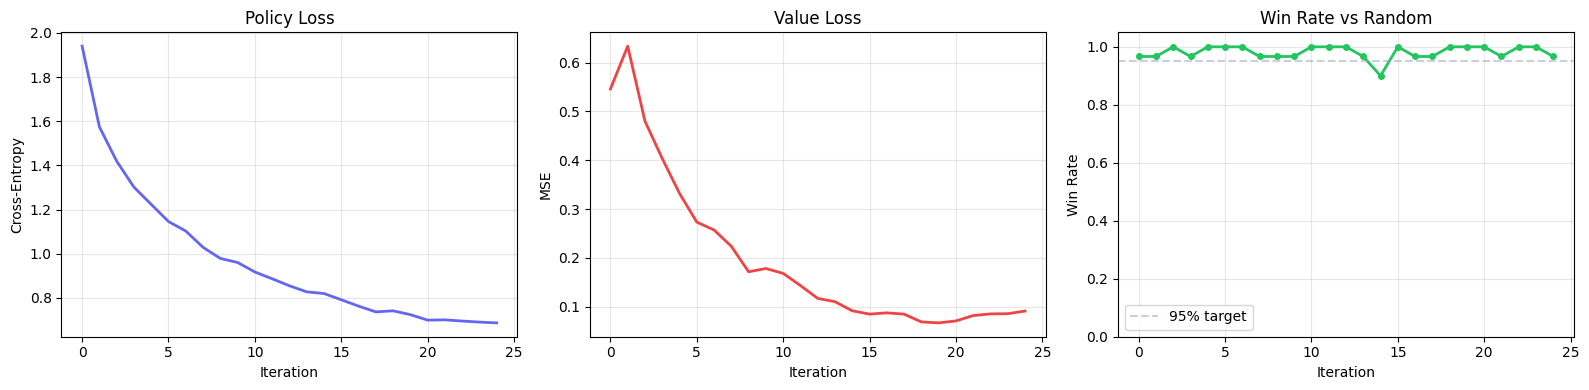

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(history['policy_losses'], color='#6366f1', linewidth=2)
ax.set_title('Policy Loss')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cross-Entropy')

ax = axes[1]
ax.plot(history['value_losses'], color='#ef4444', linewidth=2)
ax.set_title('Value Loss')
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE')

ax = axes[2]
ax.plot(history['win_rates'], color='#22c55e', linewidth=2, marker='o', markersize=4)
ax.set_title('Win Rate vs Random')
ax.set_xlabel('Iteration')
ax.set_ylabel('Win Rate')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.95, color='#94a3b8', linestyle='--', alpha=0.5, label='95% target')
ax.legend()

plt.tight_layout()
plt.show()

## 8. AlphaZero vs Minimax — The Final Test

The ultimate benchmark: can our self-taught agent hold its own against the **perfect** player?
With enough MCTS simulations, AlphaZero should draw nearly every game (the optimal outcome for Tic-Tac-Toe).

In [24]:
trained_net.eval()

def az_greedy(game):
    probs, _ = alphazero_mcts(game, trained_net, num_simulations=100, temperature=0)
    return np.argmax(probs)

# AlphaZero (X) vs Minimax (O)
print("AlphaZero (X) vs Minimax (O) — 50 games:")
results_xo = [play_game(az_greedy, minimax_player) for _ in range(50)]
print(f"  X wins: {results_xo.count(1)}  |  O wins: {results_xo.count(-1)}  |  Draws: {results_xo.count(0)}")

# Minimax (X) vs AlphaZero (O) 
print("\nMinimax (X) vs AlphaZero (O) — 50 games:")
results_ox = [play_game(minimax_player, az_greedy) for _ in range(50)]
print(f"  X wins: {results_ox.count(1)}  |  O wins: {results_ox.count(-1)}  |  Draws: {results_ox.count(0)}")

# AlphaZero vs Random (final evaluation)
print("\nAlphaZero (X) vs Random (O) — 100 games:")
results_rand = [play_game(az_greedy, random_player) for _ in range(100)]
print(f"  X wins: {results_rand.count(1)}  |  O wins: {results_rand.count(-1)}  |  Draws: {results_rand.count(0)}")

AlphaZero (X) vs Minimax (O) — 50 games:
  X wins: 0  |  O wins: 0  |  Draws: 50

Minimax (X) vs AlphaZero (O) — 50 games:
  X wins: 0  |  O wins: 0  |  Draws: 50

AlphaZero (X) vs Random (O) — 100 games:
  X wins: 100  |  O wins: 0  |  Draws: 0


In [25]:
# Visualize one game: AlphaZero vs Minimax with MCTS policy heatmaps
print("=== AlphaZero (X) vs Minimax (O) — Annotated Game ===\n")

game = TicTacToe()
move_num = 0

while not game.done:
    move_num += 1
    if game.current_player == 1:
        # AlphaZero's turn
        probs, value = alphazero_mcts(game, trained_net, num_simulations=100, temperature=0)
        action = np.argmax(probs)
        
        # Show the MCTS policy as a 3x3 grid
        policy_grid = probs.reshape(3, 3)
        print(f"Move {move_num} — AlphaZero (X), value estimate: {value:+.2f}")
        print(f"  MCTS policy (visit %):")
        for r in range(3):
            row_str = '  '.join(f'{policy_grid[r, c]:.2f}' for c in range(3))
            print(f"    {row_str}")
    else:
        # Minimax's turn
        action = minimax_player(game)
        print(f"Move {move_num} — Minimax (O)")
    
    print(f"  → plays cell {action} (row {action//3}, col {action%3})")
    game.step(action)
    game.render()

=== AlphaZero (X) vs Minimax (O) — Annotated Game ===

Move 1 — AlphaZero (X), value estimate: -0.07
  MCTS policy (visit %):
    0.00  0.00  0.00
    0.00  1.00  0.00
    0.00  0.00  0.00
  → plays cell 4 (row 1, col 1)
  0 1 2
0 . . .
1 . X .
2 . . .
  [ongoing]

Move 2 — Minimax (O)
  → plays cell 0 (row 0, col 0)
  0 1 2
0 O . .
1 . X .
2 . . .
  [ongoing]

Move 3 — AlphaZero (X), value estimate: +0.01
  MCTS policy (visit %):
    0.00  1.00  0.00
    0.00  0.00  0.00
    0.00  0.00  0.00
  → plays cell 1 (row 0, col 1)
  0 1 2
0 O X .
1 . X .
2 . . .
  [ongoing]

Move 4 — Minimax (O)
  → plays cell 7 (row 2, col 1)
  0 1 2
0 O X .
1 . X .
2 . O .
  [ongoing]

Move 5 — AlphaZero (X), value estimate: +0.00
  MCTS policy (visit %):
    0.00  0.00  0.00
    0.00  0.00  0.00
    1.00  0.00  0.00
  → plays cell 6 (row 2, col 0)
  0 1 2
0 O X .
1 . X .
2 X O .
  [ongoing]

Move 6 — Minimax (O)
  → plays cell 2 (row 0, col 2)
  0 1 2
0 O X O
1 . X .
2 X O .
  [ongoing]

Move 7 — AlphaZero

## Recap

### Key Equations

| Component | Formula |
| :--- | :--- |
| **Minimax** | $V(s) = \max_a V(\text{result}(s,a))$ (negamax) |
| **UCB1** | $\frac{W}{N} + c\sqrt{\frac{\ln N_{\text{parent}}}{N}}$ |
| **PUCT** | $\frac{W}{N} + c_{\text{puct}} \cdot p_a \cdot \frac{\sqrt{N_{\text{parent}}}}{1+N}$ |
| **AlphaZero Loss** | $(z - v)^2 - \boldsymbol{\pi}^T \log \mathbf{p}$ |

### What We Learned
1. **Minimax** solves games perfectly but is exponentially expensive
2. **MCTS** searches selectively using UCB1 to balance exploration and exploitation
3. **AlphaZero** replaces random rollouts with a neural network (policy + value heads)
4. **PUCT** uses the network's policy prior to guide the tree search
5. **Self-play** creates an infinite curriculum — MCTS produces better training targets than the raw network, and the trained network makes MCTS better

---

### Next Up: The Hidden Board

AlphaZero conquered chess and Go — games of **perfect information** where both players see the full board.
But what about **poker**, where you can't see your opponent's cards?

MCTS breaks completely when information is hidden. We'll need a fundamentally different algorithm:
**Counterfactual Regret Minimization (CFR)** — and we'll discover that **bluffing** emerges
naturally from the math.